In [1]:
%pip install xgboost seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
TEST_SIZE = 0.20

print("Import thư viện thành công!")
print("RANDOM_STATE =", RANDOM_STATE)
print("TEST_SIZE =", TEST_SIZE)

Import thư viện thành công!
RANDOM_STATE = 42
TEST_SIZE = 0.2


In [3]:
DATA_PATH = Path("train.csv")

PROCESSED_DIR = Path("data/processed")
FIGURE_DIR = Path("figures")
MODEL_DIR = Path("models")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("File tồn tại:", DATA_PATH.exists())
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FIGURE_DIR:", FIGURE_DIR)
print("MODEL_DIR:", MODEL_DIR)

DATA_PATH: train.csv
File tồn tại: True
PROCESSED_DIR: data\processed
FIGURE_DIR: figures
MODEL_DIR: models


In [4]:
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("THÔNG TIN DATASET")
print("=" * 60)

print("Số mẫu:", df.shape[0])
print("Số cột:", df.shape[1])
print("Số feature:", df.shape[1] - 1)
print("Target: SalePrice")

display(df.head())

THÔNG TIN DATASET
Số mẫu: 1460
Số cột: 81
Số feature: 80
Target: SalePrice


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
print("PHÂN BỐ KIỂU DỮ LIỆU")
print("=" * 60)

dtype_table = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str)
})

display(dtype_table)

print("\nSố lượng theo kiểu dữ liệu:")
print(df.dtypes.value_counts())

PHÂN BỐ KIỂU DỮ LIỆU


,Data_Type
Id,int64
MSSubClass,int64
MSZoning,str
LotFrontage,float64
LotArea,int64
Street,str
Alley,str
LotShape,str
LandContour,str
Utilities,str



Số lượng theo kiểu dữ liệu:
str        43
int64      35
float64     3
Name: count, dtype: int64


In [6]:
print("THỐNG KÊ MÔ TẢ SALEPRICE")
print("=" * 60)

display(df["SalePrice"].describe().to_frame())

print("Median SalePrice:", df["SalePrice"].median())
print("Missing SalePrice:", df["SalePrice"].isna().sum())

THỐNG KÊ MÔ TẢ SALEPRICE


,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


Median SalePrice: 163000.0
Missing SalePrice: 0


In [7]:
duplicate_count = df.duplicated().sum()

print("Số dòng trùng lặp:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Đã loại bỏ các dòng trùng lặp.")
else:
    print("Dataset không có dòng trùng lặp.")

Số dòng trùng lặp: 0
Dataset không có dòng trùng lặp.


In [8]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percent": missing_percent
})

missing_table = (
    missing_table[missing_table["Missing_Count"] > 0]
    .sort_values("Missing_Count", ascending=False)
)

print("Số cột có missing value:", len(missing_table))

display(missing_table.round(2))

Số cột có missing value: 19


,Missing_Count,Missing_Percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


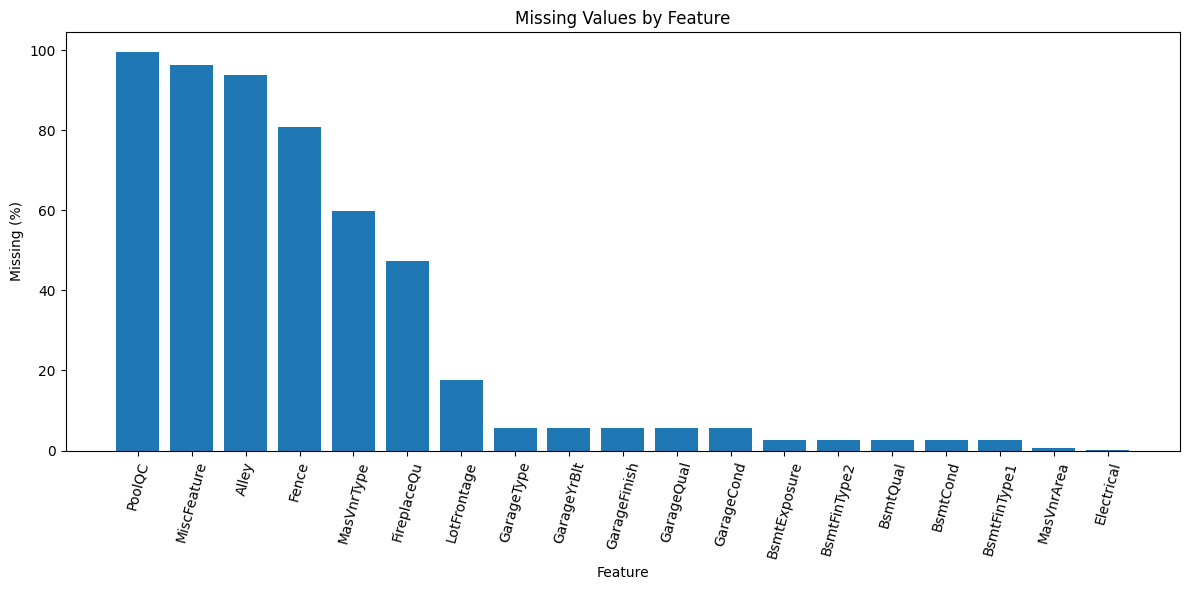

In [9]:
plt.figure(figsize=(12, 6))

plt.bar(
    missing_table.index,
    missing_table["Missing_Percent"]
)

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing (%)")
plt.xticks(rotation=75)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "missing_values.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

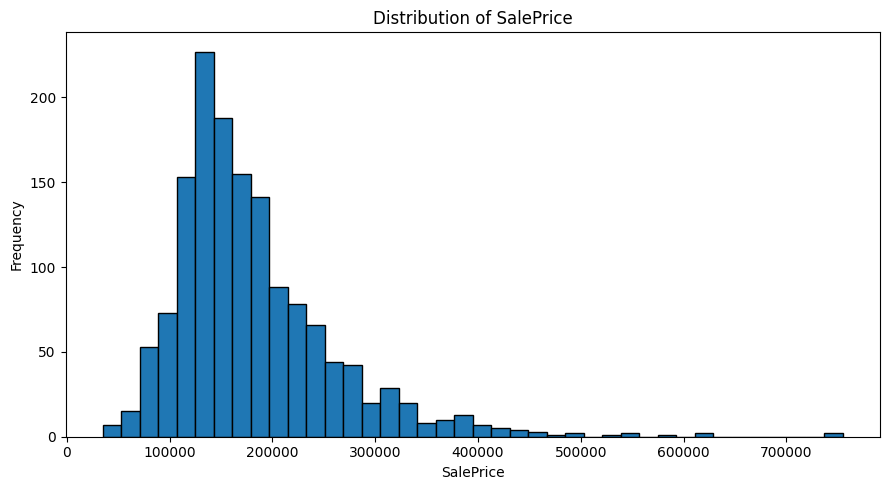

Skewness của SalePrice: 1.8829


In [10]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["SalePrice"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "saleprice_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    "Skewness của SalePrice:",
    round(df["SalePrice"].skew(), 4)
)

In [11]:
df["log_SalePrice"] = np.log1p(df["SalePrice"])

print(
    "Skewness trước log:",
    round(df["SalePrice"].skew(), 4)
)

print(
    "Skewness sau log:",
    round(df["log_SalePrice"].skew(), 4)
)

Skewness trước log: 1.8829
Skewness sau log: 0.1213


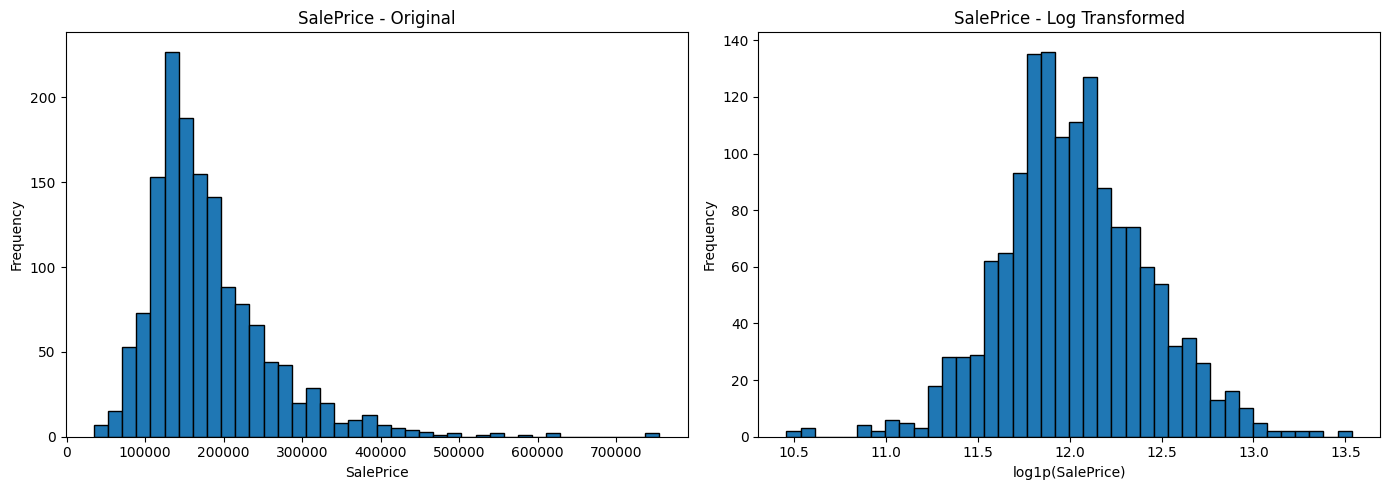

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["SalePrice"],
    bins=40,
    edgecolor="black"
)

axes[0].set_title("SalePrice - Original")
axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("Frequency")


axes[1].hist(
    df["log_SalePrice"],
    bins=40,
    edgecolor="black"
)

axes[1].set_title("SalePrice - Log Transformed")
axes[1].set_xlabel("log1p(SalePrice)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "saleprice_before_after_log.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

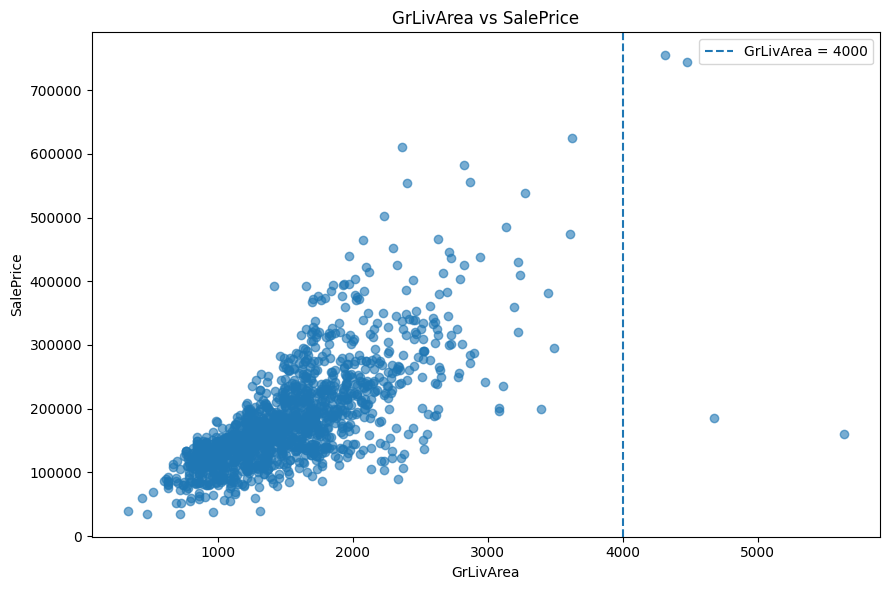

In [13]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["GrLivArea"],
    df["SalePrice"],
    alpha=0.6
)

plt.axvline(
    x=4000,
    linestyle="--",
    label="GrLivArea = 4000"
)

plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "grlivarea_outliers.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [14]:
outlier_table = df.loc[
    df["GrLivArea"] > 4000,
    ["Id", "GrLivArea", "SalePrice"]
].sort_values("GrLivArea")

print("Các mẫu có GrLivArea > 4000:")
display(outlier_table)

Các mẫu có GrLivArea > 4000:


,Id,GrLivArea,SalePrice
691,692,4316,755000
1182,1183,4476,745000
523,524,4676,184750
1298,1299,5642,160000


In [15]:
outlier_condition = (
    (df["GrLivArea"] > 4000)
    & (df["SalePrice"] < 300000)
)

print("Số outlier cần loại:", outlier_condition.sum())

display(
    df.loc[
        outlier_condition,
        ["Id", "GrLivArea", "SalePrice"]
    ]
)

df = df.loc[~outlier_condition].copy()
df.reset_index(drop=True, inplace=True)

print("Số mẫu sau khi loại outlier:", len(df))

Số outlier cần loại: 2


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


Số mẫu sau khi loại outlier: 1458


In [16]:
# Tổng diện tích
df["TotalSF"] = (
    df["TotalBsmtSF"].fillna(0)
    + df["1stFlrSF"].fillna(0)
    + df["2ndFlrSF"].fillna(0)
)

# Tuổi nhà tại thời điểm bán
df["HouseAge"] = (
    df["YrSold"] - df["YearBuilt"]
)

# Khoảng thời gian từ lần sửa gần nhất đến lúc bán
df["RemodAge"] = (
    df["YrSold"] - df["YearRemodAdd"]
)

# Tổng số phòng tắm quy đổi
df["TotalBath"] = (
    df["FullBath"].fillna(0)
    + 0.5 * df["HalfBath"].fillna(0)
    + df["BsmtFullBath"].fillna(0)
    + 0.5 * df["BsmtHalfBath"].fillna(0)
)

new_features = [
    "TotalSF",
    "HouseAge",
    "RemodAge",
    "TotalBath"
]

print("Các feature mới:")
print(new_features)

display(df[new_features].head())

Các feature mới:
['TotalSF', 'HouseAge', 'RemodAge', 'TotalBath']


,TotalSF,HouseAge,RemodAge,TotalBath
0,2566,5,5,3.5
1,2524,31,31,2.5
2,2706,7,6,3.5
3,2473,91,36,2.0
4,3343,8,8,3.5


In [17]:
none_cols = [
    "Alley",
    "MasVnrType",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature"
]

for col in none_cols:
    if col in df.columns:
        df[col] = df[col].fillna("None")

print("Đã xử lý missing mang ý nghĩa 'không có'.")

Đã xử lý missing mang ý nghĩa 'không có'.


In [18]:
quality_map = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

quality_cols = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC"
]

encoded_cols = []

for col in quality_cols:
    if col in df.columns:
        df[col] = df[col].map(quality_map)
        encoded_cols.append(col)

print("Các cột đã Ordinal Encode:")
print(encoded_cols)

Các cột đã Ordinal Encode:
['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']


In [19]:
y = df["log_SalePrice"].copy()

X = df.drop(
    columns=[
        "Id",
        "SalePrice",
        "log_SalePrice"
    ],
    errors="ignore"
).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Số feature trước preprocessing:", X.shape[1])

X shape: (1458, 83)
y shape: (1458,)
Số feature trước preprocessing: 83


In [20]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("X_train:", X_train_raw.shape)
print("X_test :", X_test_raw.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1166, 83)
X_test : (292, 83)
y_train: (1166,)
y_test : (292,)


In [21]:
numeric_features = (
    X_train_raw
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = (
    X_train_raw
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print(
    "Tổng:",
    len(numeric_features)
    + len(categorical_features)
)

Numeric features: 50
Categorical features: 33
Tổng: 83


In [22]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

try:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            onehot
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Đã tạo preprocessing pipeline.")

Đã tạo preprocessing pipeline.


In [23]:
X_train_processed = preprocessor.fit_transform(
    X_train_raw
)

X_test_processed = preprocessor.transform(
    X_test_raw
)

print("Preprocessing hoàn tất.")

print(
    "X_train sau preprocessing:",
    X_train_processed.shape
)

print(
    "X_test sau preprocessing:",
    X_test_processed.shape
)

Preprocessing hoàn tất.
X_train sau preprocessing: (1166, 262)
X_test sau preprocessing: (292, 262)


In [24]:
feature_names = preprocessor.get_feature_names_out()

feature_names = [
    name
    .replace("num__", "")
    .replace("cat__", "")
    for name in feature_names
]

print(
    "Số feature trước preprocessing:",
    X_train_raw.shape[1]
)

print(
    "Số feature sau preprocessing:",
    len(feature_names)
)

print("\n20 feature đầu:")
print(feature_names[:20])

Số feature trước preprocessing: 83
Số feature sau preprocessing: 262

20 feature đầu:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF']


In [25]:
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

print("X_train_processed:")
print(X_train_processed.shape)

display(X_train_processed.head())

X_train_processed:
(1166, 262)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,TotalSF,HouseAge,RemodAge,TotalBath,...,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_SBrkr,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,GarageFinish_Fin,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_N,PavedDrive_P,PavedDrive_Y,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_Gar2,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-0.857409,0.017096,-0.207656,-0.781412,0.372581,-0.459933,-1.346989,-0.580392,-0.665758,2.614323,-0.538915,0.122435,1.103191,-0.298095,-0.375110,0.635096,-1.165102,0.419702,-0.791478,-0.11135,-0.391102,1.098561,-0.250902,-1.014654,-0.761581,0.148858,-0.226848,-0.755676,-0.950349,-0.951228,-1.004431,-0.887749,-1.017111,-0.822948,0.267373,0.27098,1.206124,-0.709291,-0.354602,-0.123879,-0.275268,-0.064936,-0.061394,-0.090391,-0.121665,1.657667,0.091628,0.532180,1.455425,-0.272807,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.078786,-0.503746,-0.260606,-0.053675,1.268311,0.731291,0.447637,-0.580392,1.078678,-0.223946,0.591255,0.122435,-1.027807,-0.298095,0.544004,-0.608225,-0.128072,-0.983472,0.972939,-0.11135,0.118277,-0.813263,-0.250902,0.783350,1.216154,0.148858,-0.226848,-0.755676,0.294715,0.600005,0.656798,0.615384,0.318420,-0.421258,0.267373,0.27098,-0.747843,-0.113220,-0.354602,-0.123879,-0.275268,-0.064936,-0.061394,-0.090391,-0.494003,0.904417,-0.242249,-0.690817,-0.389854,0.368509,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.857409,-0.030253,-0.174738,-0.781412,0.372581,-0.029769,-0.716444,-0.137330,-0.665758,-0.223946,-0.538915,0.122435,0.885931,-0.298095,-0.867412,-0.118139,-1.165102,-0.430376,-0.791478,-0.11135,-1.009492,1.098561,-0.250902,-1.014654,-0.761581,0.148858,-0.226848,-0.755676,-0.950349,-0.951228,-1.004431,-0.219690,0.318420,2.016904,0.267373,0.27098,-0.747843,-0.709291,-0.354602,-0.123879,-0.275268,-0.064936,-0.061394,-0.090391,0.623013,0.904417,-0.715887,0.069425,0.775585,-0.272807,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.155263,-0.456397,-0.320515,-0.781412,1.268311,-1.121725,-1.686513,0.888710,-0.665758,-0.223946,0.591255,0.122435,0.287310,-0.298095,-0.894511,-0.772392,0.908958,-0.487593,1.007222,-0.11135,0.508735,1.098561,-0.250902,-1.014654,1.216154,0.148858,-0.226848,0.766117,0.294715,2.151238,0.656798,-1.639316,-1.017111,-1.075171,0.267373,0.27098,-0.747843,-0.709291,4.042204,-0.123879,-0.275268,-0.064936,-0.061394,-0.090391,-0.121665,-0.602083,-0.075311,1.094098,1.649665,0.368509,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0

In [26]:
print("=" * 60)
print("KIỂM TRA DỮ LIỆU SAU PREPROCESSING")
print("=" * 60)

print(
    "Missing X_train:",
    X_train_processed.isna().sum().sum()
)

print(
    "Missing X_test:",
    X_test_processed.isna().sum().sum()
)

print(
    "Infinity X_train:",
    np.isinf(
        X_train_processed.to_numpy()
    ).sum()
)

print(
    "Infinity X_test:",
    np.isinf(
        X_test_processed.to_numpy()
    ).sum()
)

KIỂM TRA DỮ LIỆU SAU PREPROCESSING
Missing X_train: 0
Missing X_test: 0
Infinity X_train: 0
Infinity X_test: 0


In [27]:
X_train_processed = X_train_processed.reset_index(drop=True)
X_test_processed = X_test_processed.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Reset index hoàn tất.")

Reset index hoàn tất.


In [28]:
X_train_processed.to_csv(
    PROCESSED_DIR / "X_train.csv",
    index=False
)

X_test_processed.to_csv(
    PROCESSED_DIR / "X_test.csv",
    index=False
)

y_train.to_frame(
    name="log_SalePrice"
).to_csv(
    PROCESSED_DIR / "y_train.csv",
    index=False
)

y_test.to_frame(
    name="log_SalePrice"
).to_csv(
    PROCESSED_DIR / "y_test.csv",
    index=False
)

pd.DataFrame({
    "feature": feature_names
}).to_csv(
    PROCESSED_DIR / "feature_names.csv",
    index=False
)

print("Đã lưu:")
print("- X_train.csv")
print("- X_test.csv")
print("- y_train.csv")
print("- y_test.csv")
print("- feature_names.csv")

Đã lưu:
- X_train.csv
- X_test.csv
- y_train.csv
- y_test.csv
- feature_names.csv


In [29]:
joblib.dump(
    preprocessor,
    MODEL_DIR / "preprocessor.pkl"
)

print("Đã lưu models/preprocessor.pkl")

Đã lưu models/preprocessor.pkl


tv3

In [30]:
import sys, json, time, hashlib
from pathlib import Path
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV

ROOT = Path.cwd()
if not (ROOT / 'data/processed/X_train.csv').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.evaluate import evaluate_model, RESULT_COLUMNS
from src.models import make_models, DEFAULT_PARAMS, PARAMS_FILE, RANDOM_STATE, N_SPLITS

DATA, FIG, MODELS = ROOT / 'data/processed', ROOT / 'figures', ROOT / 'models'
FIG.mkdir(exist_ok=True); MODELS.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})

In [31]:
X_train = pd.read_csv(DATA / 'X_train.csv'); X_test = pd.read_csv(DATA / 'X_test.csv')
y_train = pd.read_csv(DATA / 'y_train.csv').squeeze('columns'); y_test = pd.read_csv(DATA / 'y_test.csv').squeeze('columns')
feature_names = pd.read_csv(DATA / 'feature_names.csv')['feature'].tolist()

assert list(X_train.columns) == feature_names == list(X_test.columns), 'Tên/thứ tự cột không khớp feature_names.csv'
assert X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0, 'Còn giá trị thiếu'
assert len(X_train) == len(y_train) and len(X_test) == len(y_test)
assert 9 < y_train.min() and y_train.max() < 15, 'y phải là log1p(SalePrice)'

print(f'Train: {X_train.shape} | Test: {X_test.shape} | Số feature: {len(feature_names)}')
print(f'Tỷ lệ test = {len(X_test) / (len(X_train) + len(X_test)):.2f}')
print('Dấu vân tay dữ liệu (md5 của X_train):', hashlib.md5(pd.util.hash_pandas_object(X_train).values.tobytes()).hexdigest()[:10])
print(f'log_SalePrice: train trung bình {y_train.mean():.3f}, độ lệch chuẩn {y_train.std():.3f}')

Train: (1166, 262) | Test: (292, 262) | Số feature: 262
Tỷ lệ test = 0.20
Dấu vân tay dữ liệu (md5 của X_train): 3d6b59af9c
log_SalePrice: train trung bình 12.023, độ lệch chuẩn 0.397


In [32]:
floor = evaluate_model('floor', 'MeanPredictor', DummyRegressor(), X_train, y_train, X_test, y_test, N_SPLITS, RANDOM_STATE)
assert list(floor) == RESULT_COLUMNS
print(f"Mức sàn (dự đoán trung bình): CV log RMSE = {floor['cv_log_rmse']:.4f} | R2 CV = {floor['cv_log_r2']:.3f}")

Mức sàn (dự đoán trung bình): CV log RMSE = 0.3963 | R2 CV = -0.007


In [33]:
RUN_SEARCH = True
TUNE_SEED = 7
SPACES = {
    'SVR': ({'svr__C': [1, 3, 10, 30, 100], 'svr__epsilon': [0.005, 0.01, 0.05, 0.1],
             'svr__gamma': ['scale', 0.0005, 0.001, 0.003, 0.01]}, 25),
    'RandomForest': ({'max_features': [0.2, 0.33, 0.5, 0.8], 'min_samples_leaf': [1, 2, 3, 5],
                      'max_depth': [None, 20, 40]}, 12),
    'XGBoost': ({'n_estimators': [300, 500, 800], 'learning_rate': [0.02, 0.03, 0.05, 0.08],
                 'max_depth': [2, 3, 4, 5], 'min_child_weight': [1, 3, 5],
                 'subsample': [0.6, 0.8, 1.0], 'colsample_bytree': [0.4, 0.6, 0.8],
                 'reg_lambda': [1, 3, 10], 'reg_alpha': [0, 0.01, 0.1]}, 30),
}

def plain(v):
    return v.item() if hasattr(v, 'item') else v

if RUN_SEARCH:
    base_models = make_models(params={**DEFAULT_PARAMS, 'RandomForest': {'n_estimators': 300}})
    cv_tune = KFold(N_SPLITS, shuffle=True, random_state=TUNE_SEED)
    chosen, top_tables = {}, {}
    for name, (space, n_iter) in SPACES.items():
        t0 = time.perf_counter()
        search = RandomizedSearchCV(base_models[name], space, n_iter=n_iter, cv=cv_tune,
                                    scoring='neg_root_mean_squared_error', random_state=RANDOM_STATE,
                                    n_jobs=1, refit=False).fit(X_train, y_train)
        best = {k.replace('svr__', ''): plain(v) for k, v in search.best_params_.items()}
        chosen[name] = best
        res = pd.DataFrame(search.cv_results_)
        top_tables[name] = res.sort_values('rank_test_score').head(3)[['mean_test_score', 'std_test_score']].assign(
            cv_rmse=lambda d: -d['mean_test_score']).round(4)[['cv_rmse', 'std_test_score']]
        print(f'{name:13s} {len(res)} tổ hợp x {N_SPLITS} fold, {time.perf_counter() - t0:5.0f}s -> CV log RMSE = {-search.best_score_:.4f}')
        print('   ', best)
    chosen['RandomForest']['n_estimators'] = 300
    PARAMS_FILE.write_text(json.dumps(chosen, indent=2, ensure_ascii=False), encoding='utf-8')
    print('Đã lưu', PARAMS_FILE.relative_to(ROOT))
else:
    print('Dùng lại', json.loads(PARAMS_FILE.read_text(encoding='utf-8')))

SVR           25 tổ hợp x 5 fold,    13s -> CV log RMSE = 0.1175
    {'gamma': 0.0005, 'epsilon': 0.01, 'C': 3}
RandomForest  12 tổ hợp x 5 fold,   121s -> CV log RMSE = 0.1331
    {'min_samples_leaf': 1, 'max_features': 0.33, 'max_depth': None}
XGBoost       30 tổ hợp x 5 fold,   131s -> CV log RMSE = 0.1178
    {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Đã lưu src\hyperparams.json


In [34]:
if RUN_SEARCH:
    for name, tbl in top_tables.items():
        print(f'--- {name}: 3 cấu hình tốt nhất (CV log RMSE, độ lệch chuẩn giữa các fold)')
        print(tbl.to_string(index=False))

--- SVR: 3 cấu hình tốt nhất (CV log RMSE, độ lệch chuẩn giữa các fold)
 cv_rmse  std_test_score
  0.1175          0.0116
  0.1192          0.0104
  0.1258          0.0112
--- RandomForest: 3 cấu hình tốt nhất (CV log RMSE, độ lệch chuẩn giữa các fold)
 cv_rmse  std_test_score
  0.1331          0.0105
  0.1332          0.0110
  0.1339          0.0108
--- XGBoost: 3 cấu hình tốt nhất (CV log RMSE, độ lệch chuẩn giữa các fold)
 cv_rmse  std_test_score
  0.1178          0.0124
  0.1188          0.0122
  0.1189          0.0114


In [35]:
models = make_models()
rows, fitted = [], {}
for name, model in models.items():
    row, fitted[name] = evaluate_model('baseline', name, model, X_train, y_train, X_test, y_test,
                                       N_SPLITS, RANDOM_STATE, detailed=True, return_model=True)
    rows.append(row)
    print(f"{name:13s} CV log RMSE = {row['cv_log_rmse']:.4f} (+/- {row['cv_log_rmse_std']:.4f}) | test = {row['test_log_rmse']:.4f} | {row['cv_seconds']:.1f}s")
extended = pd.DataFrame(rows).sort_values('cv_log_rmse').reset_index(drop=True)
results = extended[RESULT_COLUMNS]

SVR           CV log RMSE = 0.1183 (+/- 0.0109) | test = 0.1220 | 0.6s
RandomForest  CV log RMSE = 0.1301 (+/- 0.0147) | test = 0.1388 | 10.0s
XGBoost       CV log RMSE = 0.1160 (+/- 0.0118) | test = 0.1149 | 3.5s


In [36]:
results.round(4)

,technique,model,n_features,cv_log_rmse,cv_log_r2,test_log_rmse,test_original_rmse,test_original_mae,test_original_r2,cv_seconds,train_seconds
0,baseline,XGBoost,262,0.1160,0.9137,0.1149,18924.4448,13884.4097,0.9352,3.4752,0.7044
1,baseline,SVR,262,0.1183,0.9102,0.1220,20351.7845,13973.4990,0.9250,0.6450,0.1213
2,baseline,RandomForest,262,0.1301,0.8917,0.1388,22379.6502,15548.8328,0.9093,10.0377,2.3861


In [37]:
detail_cols = ['model', 'cv_log_rmse', 'cv_log_rmse_std', 'cv_log_mae', 'cv_log_r2', 'cv_original_rmse', 'cv_original_mae', 'cv_original_r2',
               'test_log_rmse', 'test_log_mae', 'test_log_r2', 'test_original_rmse', 'test_original_mae', 'test_original_r2']
extended[detail_cols].round(4).set_index('model').T

model,XGBoost,SVR,RandomForest
cv_log_rmse,0.1160,0.1183,0.1301
cv_log_rmse_std,0.0118,0.0109,0.0147
cv_log_mae,0.0793,0.0795,0.0889
cv_log_r2,0.9137,0.9102,0.8917
cv_original_rmse,23110.9085,23418.5500,26445.3321
cv_original_mae,14206.5087,13850.9953,16152.0867
cv_original_r2,0.9161,0.9123,0.8909
test_log_rmse,0.1149,0.1220,0.1388
test_log_mae,0.0805,0.0817,0.0920
test_log_r2,0.9217,0.9117,0.8858


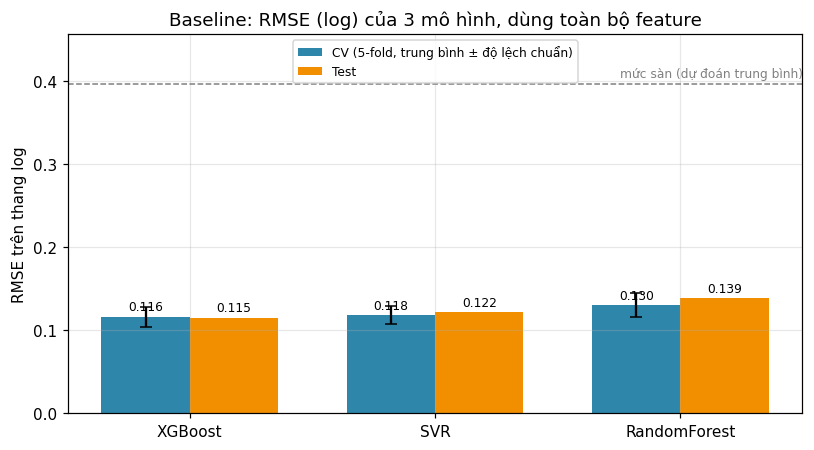

In [38]:
order = extended['model'].tolist(); x = np.arange(len(order)); w = 0.36
fig, ax = plt.subplots(figsize=(7.5, 4.2))
b1 = ax.bar(x - w / 2, extended['cv_log_rmse'], w, yerr=extended['cv_log_rmse_std'], capsize=4, label='CV (5-fold, trung bình ± độ lệch chuẩn)', color='#2E86AB')
b2 = ax.bar(x + w / 2, extended['test_log_rmse'], w, label='Test', color='#F18F01')
ax.axhline(floor['cv_log_rmse'], ls='--', color='gray', lw=1); ax.text(len(order) - .5, floor['cv_log_rmse'] * 1.01, 'mức sàn (dự đoán trung bình)', ha='right', va='bottom', fontsize=8, color='gray')
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + .004, f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylabel('RMSE trên thang log'); ax.set_title('Baseline: RMSE (log) của 3 mô hình, dùng toàn bộ feature')
ax.set_ylim(0, floor['cv_log_rmse'] * 1.15); ax.legend(loc='upper center', fontsize=8)
fig.tight_layout(); fig.savefig(FIG / 'baseline_rmse_log.png', dpi=150); plt.show()

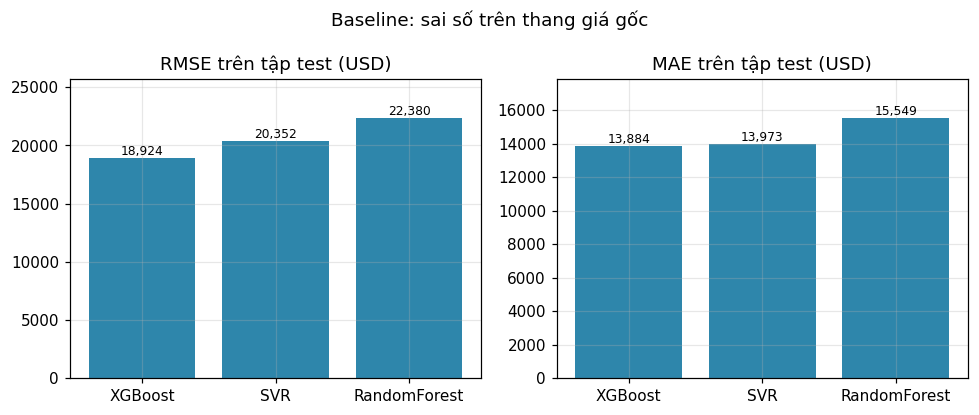

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, col, title in zip(axes, ['test_original_rmse', 'test_original_mae'], ['RMSE trên tập test (USD)', 'MAE trên tập test (USD)']):
    bars = ax.bar(order, extended[col], color='#2E86AB')
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{b.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(title); ax.set_ylim(0, extended[col].max() * 1.15)
fig.suptitle('Baseline: sai số trên thang giá gốc'); fig.tight_layout(); fig.savefig(FIG / 'baseline_error_original.png', dpi=150); plt.show()

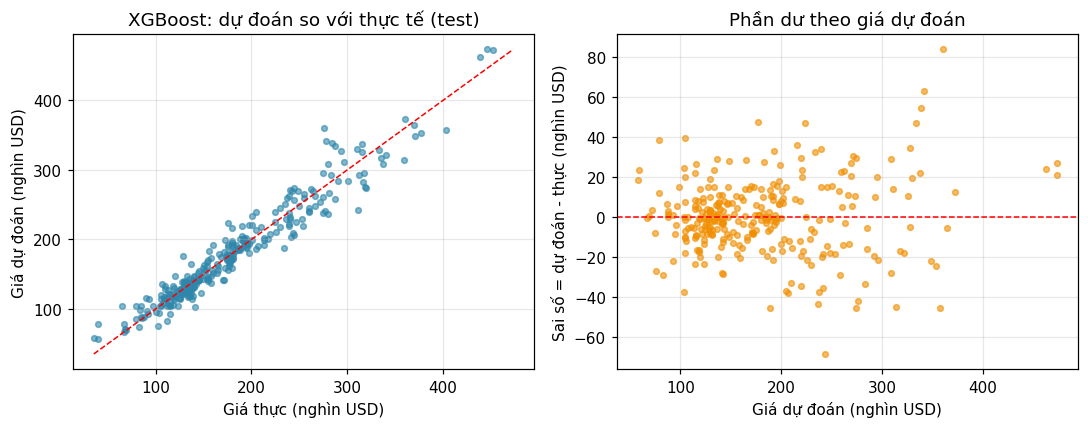

In [40]:
best_name = extended.loc[0, 'model']
pred = np.expm1(fitted[best_name].predict(X_test)); actual = np.expm1(y_test.to_numpy())
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(actual / 1e3, pred / 1e3, s=14, alpha=.6, color='#2E86AB')
lim = [min(actual.min(), pred.min()) / 1e3, max(actual.max(), pred.max()) / 1e3]; axes[0].plot(lim, lim, 'r--', lw=1)
axes[0].set(xlabel='Giá thực (nghìn USD)', ylabel='Giá dự đoán (nghìn USD)', title=f'{best_name}: dự đoán so với thực tế (test)')
axes[1].scatter(pred / 1e3, (pred - actual) / 1e3, s=14, alpha=.6, color='#F18F01'); axes[1].axhline(0, color='red', lw=1, ls='--')
axes[1].set(xlabel='Giá dự đoán (nghìn USD)', ylabel='Sai số = dự đoán - thực (nghìn USD)', title='Phần dư theo giá dự đoán')
fig.tight_layout(); fig.savefig(FIG / 'baseline_pred_vs_actual.png', dpi=150); plt.show()

In [41]:
best = extended.iloc[0]; worst = extended.iloc[-1]; gap = extended['cv_log_rmse'].diff().iloc[1] if len(extended) > 1 else float('nan')
print(f"1. Mô hình tốt nhất theo CV log RMSE: {best['model']} ({best['cv_log_rmse']:.4f}); kém nhất: {worst['model']} ({worst['cv_log_rmse']:.4f}).")
print(f"2. Khoảng cách giữa hạng 1 và hạng 2 là {gap:.4f}, độ lệch chuẩn giữa các fold của hạng 1 là {best['cv_log_rmse_std']:.4f}"
      f" -> {'chênh lệch nhỏ hơn mức nhiễu của CV' if gap < best['cv_log_rmse_std'] else 'chênh lệch lớn hơn mức nhiễu của CV'}.")
print(f"3. Sai số test của {best['model']} trên thang giá gốc: RMSE = {best['test_original_rmse']:,.0f} USD, MAE = {best['test_original_mae']:,.0f} USD, R2 = {best['test_original_r2']:.3f}.")
for _, r in extended.iterrows():
    print(f"   - {r['model']:13s} test - CV (log RMSE) = {r['test_log_rmse'] - r['cv_log_rmse']:+.4f}; fit toàn bộ train: {r['train_seconds']:.1f}s; CV: {r['cv_seconds']:.1f}s")
print(f"4. Mức sàn (dự đoán trung bình) có CV log RMSE = {floor['cv_log_rmse']:.3f}; mô hình tốt nhất giảm sai số khoảng {100 * (1 - best['cv_log_rmse'] / floor['cv_log_rmse']):.0f}%.")

1. Mô hình tốt nhất theo CV log RMSE: XGBoost (0.1160); kém nhất: RandomForest (0.1301).
2. Khoảng cách giữa hạng 1 và hạng 2 là 0.0023, độ lệch chuẩn giữa các fold của hạng 1 là 0.0118 -> chênh lệch nhỏ hơn mức nhiễu của CV.
3. Sai số test của XGBoost trên thang giá gốc: RMSE = 18,924 USD, MAE = 13,884 USD, R2 = 0.935.
   - XGBoost       test - CV (log RMSE) = -0.0011; fit toàn bộ train: 0.7s; CV: 3.5s
   - SVR           test - CV (log RMSE) = +0.0037; fit toàn bộ train: 0.1s; CV: 0.6s
   - RandomForest  test - CV (log RMSE) = +0.0086; fit toàn bộ train: 2.4s; CV: 10.0s
4. Mức sàn (dự đoán trung bình) có CV log RMSE = 0.396; mô hình tốt nhất giảm sai số khoảng 71%.


In [42]:
results.to_csv(DATA / 'baseline_results.csv', index=False)
extended.to_csv(DATA / 'baseline_results_extended.csv', index=False)
joblib.dump(fitted[best_name], MODELS / 'baseline_best_model.pkl')
import sklearn, xgboost
print('Mô hình tốt nhất đã lưu:', best_name, '| sklearn', sklearn.__version__, '| xgboost', xgboost.__version__, '| pandas', pd.__version__)
for p in [DATA / 'baseline_results.csv', MODELS / 'baseline_best_model.pkl', PARAMS_FILE, FIG / 'baseline_rmse_log.png']:
    assert p.exists(), p
assert list(pd.read_csv(DATA / 'baseline_results.csv').columns) == RESULT_COLUMNS
print('Đã lưu đủ file bàn giao.')

Mô hình tốt nhất đã lưu: XGBoost | sklearn 1.8.0 | xgboost 3.4.1 | pandas 3.0.2
Đã lưu đủ file bàn giao.


# **TV4**

In [43]:
from functools import partial
from sklearn.base import clone
from sklearn.feature_selection import RFE, SelectKBest, f_regression, mutual_info_regression
from sklearn.linear_model import Ridge
from src.models import K_FEATURES
from src.evaluate import regression_scores
import seaborn as sns

N_ALL = X_train.shape[1]                      # tổng số feature sau tiền xử lý
K_GRID = [10, 20, 30, 50, 80, 120, 180, N_ALL]  # quét k; k = N_ALL tương đương baseline
FS_TECHNIQUES = ['filter_kbest', 'filter_mi', 'wrapper_rfe']
MODEL_ORDER = ['SVR', 'RandomForest', 'XGBoost']
print('Số feature:', N_ALL, '| K =', K_FEATURES, '| lưới k:', K_GRID)

Số feature: 262 | K = 50 | lưới k: [10, 20, 30, 50, 80, 120, 180, 262]


In [44]:
def make_selector(technique, model_name, model, k=K_FEATURES):
    """Bộ chọn feature chưa fit."""
    if technique == 'filter_kbest':   # Filter 1: F-test (tương quan tuyến tính với target)
        return SelectKBest(f_regression, k=k)
    if technique == 'filter_mi':      # Filter 2: Mutual Information (bắt cả quan hệ phi tuyến)
        return SelectKBest(partial(mutual_info_regression, random_state=RANDOM_STATE), k=k)
    if technique == 'wrapper_rfe':    # Wrapper: mỗi vòng loại 10% feature kém quan trọng nhất
        # SVR (RBF) không có coef_ nên xếp hạng bằng Ridge; RF/XGBoost dùng chính mô hình (feature_importances_)
        estimator = Ridge(alpha=1.0) if model_name == 'SVR' else clone(model)
        return RFE(estimator, n_features_to_select=k, step=0.1)
    raise ValueError(technique)


def make_fs_pipeline(technique, model_name, model, k=K_FEATURES):
    """Pipeline(bộ chọn -> mô hình); bộ chọn được fit lại trong từng fold của CV."""
    return Pipeline([('select', make_selector(technique, model_name, model, k)), ('model', clone(model))])


def cv_log_rmse(model, X, y, n_splits=N_SPLITS, seed=RANDOM_STATE):
    """Chỉ CV trên train (không chạm test) - dùng cho quét k. Cùng KFold với evaluate_model."""
    scores = []
    for fit_idx, val_idx in KFold(n_splits, shuffle=True, random_state=seed).split(X):
        m = clone(model).fit(X.iloc[fit_idx], y.iloc[fit_idx])
        scores.append(regression_scores(y.iloc[val_idx].to_numpy(), m.predict(X.iloc[val_idx]))['log_rmse'])
    return float(np.mean(scores)), float(np.std(scores, ddof=1))

In [45]:
fs_rows, fs_selected = [], {}
for tech in FS_TECHNIQUES:
    for name, model in make_models().items():
        row, fitted_fs = evaluate_model(tech, name, make_fs_pipeline(tech, name, model), X_train, y_train, X_test, y_test,
                                        N_SPLITS, RANDOM_STATE, detailed=True, return_model=True)
        fs_rows.append(row)
        fs_selected[f'{tech}|{name}'] = fitted_fs.named_steps['select'].get_support().astype(int)
        print(f"{tech:13s} {name:13s} n={row['n_features']:3d} CV log RMSE = {row['cv_log_rmse']:.4f} (+/- {row['cv_log_rmse_std']:.4f})"
              f" | test = {row['test_log_rmse']:.4f} | {row['cv_seconds']:.1f}s")
fs_extended = pd.DataFrame(fs_rows)
fs_results = fs_extended[RESULT_COLUMNS]
fs_results.round(4)

filter_kbest  SVR           n= 50 CV log RMSE = 0.1293 (+/- 0.0132) | test = 0.1470 | 0.3s
filter_kbest  RandomForest  n= 50 CV log RMSE = 0.1358 (+/- 0.0150) | test = 0.1463 | 5.2s
filter_kbest  XGBoost       n= 50 CV log RMSE = 0.1330 (+/- 0.0134) | test = 0.1441 | 2.3s
filter_mi     SVR           n= 50 CV log RMSE = 0.1215 (+/- 0.0126) | test = 0.1339 | 6.1s
filter_mi     RandomForest  n= 50 CV log RMSE = 0.1320 (+/- 0.0152) | test = 0.1418 | 11.2s
filter_mi     XGBoost       n= 50 CV log RMSE = 0.1252 (+/- 0.0107) | test = 0.1288 | 7.7s
wrapper_rfe   SVR           n= 50 CV log RMSE = 0.1335 (+/- 0.0110) | test = 0.1322 | 0.5s
wrapper_rfe   RandomForest  n= 50 CV log RMSE = 0.1305 (+/- 0.0145) | test = 0.1399 | 84.1s
wrapper_rfe   XGBoost       n= 50 CV log RMSE = 0.1161 (+/- 0.0128) | test = 0.1134 | 25.3s


,technique,model,n_features,cv_log_rmse,cv_log_r2,test_log_rmse,test_original_rmse,test_original_mae,test_original_r2,cv_seconds,train_seconds
0,filter_kbest,SVR,50,0.1293,0.8926,0.1470,23389.5918,16475.6071,0.9010,0.2895,0.0593
1,filter_kbest,RandomForest,50,0.1358,0.8821,0.1463,23140.7745,16456.5380,0.9031,5.1557,1.1733
2,filter_kbest,XGBoost,50,0.1330,0.8866,0.1441,23000.0445,16755.1490,0.9042,2.2980,0.4289
3,filter_mi,SVR,50,0.1215,0.9049,0.1339,21647.7482,15607.3268,0.9152,6.1473,1.3707
4,filter_mi,RandomForest,50,0.1320,0.8885,0.1418,22461.2025,15683.1390,0.9087,11.1793,2.6080
5,filter_mi,XGBoost,50,0.1252,0.8994,0.1288,20127.4646,14469.7825,0.9267,7.7032,1.7965
6,wrapper_rfe,SVR,50,0.1335,0.8855,0.1322,24033.1357,16304.8309,0.8954,0.4534,0.0742
7,wrapper_rfe,RandomForest,50,0.1305,0.8911,0.1399,22188.7041,15553.9883,0.9109,84.0588,20.6211
8,wrapper_rfe,XGBoost,50,0.1161,0.9135,0.1134,18189.6193,13109.0086,0.9401,25.3297,5.6617


In [46]:
base = extended.set_index('model')
comp = fs_extended.assign(
    base_cv=lambda d: d['model'].map(base['cv_log_rmse']),
    pct_vs_baseline=lambda d: (d['cv_log_rmse'] / d['model'].map(base['cv_log_rmse']) - 1) * 100,
    time_x_baseline=lambda d: d['cv_seconds'] / d['model'].map(base['cv_seconds']))
fmt = lambda col: comp.pivot(index='technique', columns='model', values=col)[MODEL_ORDER].reindex(FS_TECHNIQUES)
print('CV log RMSE (baseline: ' + ', '.join(f"{m} {base.loc[m, 'cv_log_rmse']:.4f}" for m in MODEL_ORDER) + ')')
display(fmt('cv_log_rmse').round(4))
print('Test log RMSE (baseline: ' + ', '.join(f"{m} {base.loc[m, 'test_log_rmse']:.4f}" for m in MODEL_ORDER) + ')')
display(fmt('test_log_rmse').round(4))
print('% thay đổi CV log RMSE so với baseline (dương = tệ hơn):')
display(fmt('pct_vs_baseline').round(1))
print('Thời gian CV (giây) và số lần so với baseline:')
display(pd.concat({'giây': fmt('cv_seconds').round(1), 'x baseline': fmt('time_x_baseline').round(1)}, axis=1))

CV log RMSE (baseline: SVR 0.1183, RandomForest 0.1301, XGBoost 0.1160)


model,SVR,RandomForest,XGBoost
technique,,,
filter_kbest,0.1293,0.1358,0.1330
filter_mi,0.1215,0.1320,0.1252
wrapper_rfe,0.1335,0.1305,0.1161


Test log RMSE (baseline: SVR 0.1220, RandomForest 0.1388, XGBoost 0.1149)


model,SVR,RandomForest,XGBoost
technique,,,
filter_kbest,0.1470,0.1463,0.1441
filter_mi,0.1339,0.1418,0.1288
wrapper_rfe,0.1322,0.1399,0.1134


% thay đổi CV log RMSE so với baseline (dương = tệ hơn):


model,SVR,RandomForest,XGBoost
technique,,,
filter_kbest,9.3,4.3,14.7
filter_mi,2.7,1.4,7.9
wrapper_rfe,12.8,0.3,0.1


Thời gian CV (giây) và số lần so với baseline:


giây                      x baseline                     
model         SVR RandomForest XGBoost        SVR RandomForest XGBoost
technique                                                             
filter_kbest  0.3          5.2     2.3        0.4          0.5     0.7
filter_mi     6.1         11.2     7.7        9.5          1.1     2.2
wrapper_rfe   0.5         84.1    25.3        0.7          8.4     7.3

In [47]:
fs_selected_df = pd.DataFrame(fs_selected, index=X_train.columns)
xcols = [f'{t}|XGBoost' for t in FS_TECHNIQUES]
overlap = pd.DataFrame([[int((fs_selected_df[a] & fs_selected_df[b]).sum()) for b in xcols] for a in xcols],
                       index=FS_TECHNIQUES, columns=FS_TECHNIQUES)
print('Số feature chung giữa các cặp kỹ thuật (đường chéo = K):')
display(overlap)
common3 = fs_selected_df.index[fs_selected_df[xcols].all(axis=1)].tolist()
print(f'{len(common3)} feature được cả 3 kỹ thuật cùng chọn:')
print(common3)

Số feature chung giữa các cặp kỹ thuật (đường chéo = K):


,filter_kbest,filter_mi,wrapper_rfe
filter_kbest,50,43,33
filter_mi,43,50,36
wrapper_rfe,33,36,50


33 feature được cả 3 kỹ thuật cùng chọn:
['LotFrontage', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'ExterQual', 'BsmtQual', 'BsmtFinSF1', 'TotalBsmtSF', 'HeatingQC', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'KitchenQual', 'TotRmsAbvGrd', 'Fireplaces', 'FireplaceQu', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'WoodDeckSF', 'OpenPorchSF', 'TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'MSZoning_RM', 'BsmtFinType1_GLQ', 'CentralAir_N', 'CentralAir_Y', 'GarageType_Attchd', 'GarageType_Detchd', 'GarageFinish_Unf']


In [48]:
sweep_rows = []
for tech in ['filter_kbest', 'filter_mi']:
    for name, model in make_models().items():
        for k in K_GRID:
            est = model if k >= N_ALL else make_fs_pipeline(tech, name, model, k)   # k = N_ALL: không chọn gì = baseline
            m, s = cv_log_rmse(est, X_train, y_train)
            sweep_rows.append({'technique': tech, 'model': name, 'k': k, 'cv_log_rmse': m, 'cv_log_rmse_std': s})
        print(f'{tech:13s} {name:13s} xong')
sweep = pd.DataFrame(sweep_rows)
sweep.pivot_table(index='k', columns=['technique', 'model'], values='cv_log_rmse')[
    [(t, m) for t in ['filter_kbest', 'filter_mi'] for m in MODEL_ORDER]].round(4)

filter_kbest  SVR           xong
filter_kbest  RandomForest  xong
filter_kbest  XGBoost       xong
filter_mi     SVR           xong
filter_mi     RandomForest  xong
filter_mi     XGBoost       xong


technique filter_kbest                      filter_mi                     
model              SVR RandomForest XGBoost       SVR RandomForest XGBoost
k                                                                         
10              0.1511       0.1496  0.1461    0.1501       0.1497  0.1507
20              0.1403       0.1403  0.1387    0.1396       0.1406  0.1402
30              0.1361       0.1384  0.1374    0.1280       0.1339  0.1278
50              0.1293       0.1358  0.1330    0.1215       0.1320  0.1252
80              0.1256       0.1330  0.1284    0.1182       0.1304  0.1241
120             0.1195       0.1321  0.1226    0.1140       0.1306  0.1204
180             0.1141       0.1309  0.1176    0.1086       0.1299  0.1174
262             0.1183       0.1301  0.1160    0.1183       0.1301  0.1160

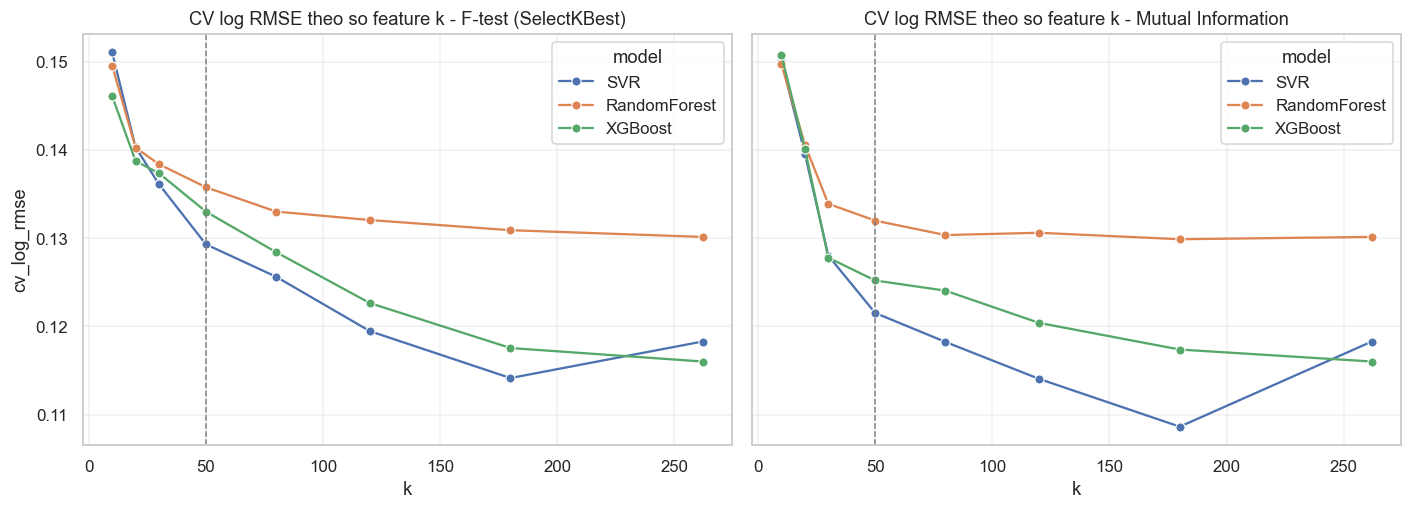

In [49]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, tech, title in zip(axes, ['filter_kbest', 'filter_mi'], ['F-test (SelectKBest)', 'Mutual Information']):
    sns.lineplot(data=sweep[sweep.technique == tech], x='k', y='cv_log_rmse', hue='model', hue_order=MODEL_ORDER, marker='o', ax=ax)
    ax.axvline(K_FEATURES, ls='--', c='gray', lw=1); ax.set_title(f'CV log RMSE theo so feature k - {title}'); ax.set_xlabel('k')
axes[0].set_ylabel('cv_log_rmse')
fig.tight_layout(); fig.savefig(FIG / 'k_sweep_filter.png', dpi=150); plt.show()
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})

In [50]:
rows = []
for (tech, name), g in sweep.groupby(['technique', 'model']):
    b = g.loc[g.cv_log_rmse.idxmin()]
    rows.append({'technique': tech, 'model': name, 'best_k': int(b.k), 'cv_best_k': b.cv_log_rmse,
                 'cv_k50': g[g.k == K_FEATURES].cv_log_rmse.item(), 'cv_baseline': g[g.k == N_ALL].cv_log_rmse.item()})
best_k = pd.DataFrame(rows).assign(gain_vs_baseline_pct=lambda d: (d.cv_best_k / d.cv_baseline - 1) * 100).round(4)
best_k

,technique,model,best_k,cv_best_k,cv_k50,cv_baseline,gain_vs_baseline_pct
0,filter_kbest,RandomForest,262,0.1301,0.1358,0.1301,0.0000
1,filter_kbest,SVR,180,0.1141,0.1293,0.1183,-3.5030
2,filter_kbest,XGBoost,262,0.1160,0.1330,0.1160,0.0000
3,filter_mi,RandomForest,180,0.1299,0.1320,0.1301,-0.2013
4,filter_mi,SVR,180,0.1086,0.1215,0.1183,-8.1621
5,filter_mi,XGBoost,262,0.1160,0.1252,0.1160,0.0000


In [51]:
print('--- Chất lượng tại K = 50 ---')
for name in MODEL_ORDER:
    sub = comp[comp.model == name].sort_values('cv_log_rmse')
    b = sub.iloc[0]
    verdict = 'tốt hơn' if b.pct_vs_baseline < 0 else 'kém hơn'
    print(f"{name:13s}: tốt nhất là {b.technique} (CV {b.cv_log_rmse:.4f} +/- {b.cv_log_rmse_std:.4f}), {verdict} baseline {b.base_cv:.4f} khoảng {abs(b.pct_vs_baseline):.1f}%"
          f" | test {b.test_log_rmse:.4f} vs baseline {base.loc[name, 'test_log_rmse']:.4f}")
print('\n--- Tốc độ ---')
slow = comp.sort_values('time_x_baseline').iloc[-1]; fast = comp.sort_values('time_x_baseline').iloc[0]
print(f"Chậm nhất: {slow.technique} + {slow.model} ({slow.cv_seconds:.0f}s, gấp {slow.time_x_baseline:.1f} lần baseline); nhanh nhất: {fast.technique} + {fast.model} ({fast.cv_seconds:.1f}s, {fast.time_x_baseline:.2f} lần baseline).")
print('\n--- Quét k ---')
for _, r in best_k.iterrows():
    print(f"{r.technique:13s} {r.model:13s}: k tốt nhất = {int(r.best_k):3d} (CV {r.cv_best_k:.4f}); {r.gain_vs_baseline_pct:+.1f}% so với toàn bộ {N_ALL} feature; tại k=50: {r.cv_k50:.4f}")
print('\n--- Mức nhiễu ---')
print(f"Độ lệch chuẩn log RMSE giữa các fold: {fs_extended.cv_log_rmse_std.min():.4f} - {fs_extended.cv_log_rmse_std.max():.4f}; chênh lệch nhỏ hơn mức này không đủ kết luận.")
print('\n--- Đồng thuận ---')
print(f"F-test ∩ MI = {overlap.loc['filter_kbest', 'filter_mi']}/{K_FEATURES}; F-test ∩ RFE = {overlap.loc['filter_kbest', 'wrapper_rfe']}/{K_FEATURES}; MI ∩ RFE = {overlap.loc['filter_mi', 'wrapper_rfe']}/{K_FEATURES}; cả ba = {len(common3)}.")

--- Chất lượng tại K = 50 ---
SVR          : tốt nhất là filter_mi (CV 0.1215 +/- 0.0126), kém hơn baseline 0.1183 khoảng 2.7% | test 0.1339 vs baseline 0.1220
RandomForest : tốt nhất là wrapper_rfe (CV 0.1305 +/- 0.0145), kém hơn baseline 0.1301 khoảng 0.3% | test 0.1399 vs baseline 0.1388
XGBoost      : tốt nhất là wrapper_rfe (CV 0.1161 +/- 0.0128), kém hơn baseline 0.1160 khoảng 0.1% | test 0.1134 vs baseline 0.1149

--- Tốc độ ---
Chậm nhất: filter_mi + SVR (6s, gấp 9.5 lần baseline); nhanh nhất: filter_kbest + SVR (0.3s, 0.45 lần baseline).

--- Quét k ---
filter_kbest  RandomForest : k tốt nhất = 262 (CV 0.1301); +0.0% so với toàn bộ 262 feature; tại k=50: 0.1358
filter_kbest  SVR          : k tốt nhất = 180 (CV 0.1141); -3.5% so với toàn bộ 262 feature; tại k=50: 0.1293
filter_kbest  XGBoost      : k tốt nhất = 262 (CV 0.1160); +0.0% so với toàn bộ 262 feature; tại k=50: 0.1330
filter_mi     RandomForest : k tốt nhất = 180 (CV 0.1299); -0.2% so với toàn bộ 262 feature; tại k=50

In [52]:
fs_results.to_csv(DATA / 'fs_results_filter_wrapper.csv', index=False)
fs_extended.to_csv(DATA / 'fs_results_filter_wrapper_extended.csv', index=False)
fs_selected_df.to_csv(DATA / 'selected_features_filter_wrapper.csv')
sweep.to_csv(DATA / 'k_sweep_filter.csv', index=False)
for p in [DATA / 'fs_results_filter_wrapper.csv', DATA / 'selected_features_filter_wrapper.csv', FIG / 'k_sweep_filter.png']:
    assert p.exists(), p
assert list(pd.read_csv(DATA / 'fs_results_filter_wrapper.csv').columns) == RESULT_COLUMNS
assert (fs_results['n_features'] == K_FEATURES).all()